# GPU-to-GPU copies on 3× CMP 170HX behind PLX switches (Gen2 x16) — no P2P, host-staged

| Metric | Value |
|---|---|
| Direct P2P | **not available** — `cuDeviceCanAccessPeer` = 0 on all 6 pairs (driver without BAR1-P2P patches) |
| Peer copy, 256 MiB | **6.2–6.3 GB/s** (driver's host-staged path; single-card D2H link = 6.68 GB/s) |
| Peer copy, 4 KiB | **22 µs** (D2H alone: 9.5 µs) |
| NCCL all-reduce, 256 MiB, 2 GPUs | **3.69 GB/s** same switch · **3.85 GB/s** across switches (bus bandwidth, SHM transport) |

![copy and all-reduce bandwidth](../assets/charts/2026-10-01-cmp170hx-3card-p2p-plx.png)

```bash
python3 results/2026-10-01-cmp170hx-3card-p2p-plx/tools/p2p_probe.py > p2p-copy.json
```

Evidence: [`results/2026-10-01-cmp170hx-3card-p2p-plx/`](../results/2026-10-01-cmp170hx-3card-p2p-plx/README.md)

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True re-runs tools/p2p_probe.py and tools/p2p_latency.py on this
# machine's GPUs (needs libcuda; no endpoint, no network).
import os

EXPERIMENT = "2026-10-01-cmp170hx-3card-p2p-plx"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
print("LIVE =", LIVE, "| receipts:", RESULTS_DIR)

LIVE = False | receipts: ../results/2026-10-01-cmp170hx-3card-p2p-plx


In [2]:
import json, statistics, subprocess, sys
from IPython.display import display, Markdown


def load(name):
    with open(os.path.join(RESULTS_DIR, name)) as f:
        return json.load(f)


def load_jsonl(name):
    with open(os.path.join(RESULTS_DIR, name)) as f:
        return [json.loads(l) for l in f if l.strip()]


def table(headers, rows):
    out = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))


if LIVE:
    copy = json.loads(subprocess.run([sys.executable, os.path.join(RESULTS_DIR, "tools/p2p_probe.py")], capture_output=True, text=True, check=True).stdout)
    lat = json.loads(subprocess.run([sys.executable, os.path.join(RESULTS_DIR, "tools/p2p_latency.py")], capture_output=True, text=True, check=True).stdout)
else:
    copy = load("p2p-copy.json")
    lat = load("p2p-latency.json")
nccl = load_jsonl("nccl-allreduce.jsonl")
env = load("environment.json")
print(len(copy["pairs"]), "ordered pairs,", len(lat["rows"]), "latency rows,", len(nccl), "all-reduce rows")

6 ordered pairs, 49 latency rows, 24 all-reduce rows


## 1. TL;DR

**Measured.** On this host, with the upstream memory unlock and no P2P driver patches, the
three cards cannot map each other's memory: every `cuDeviceCanAccessPeer` is 0 and
`cuCtxEnablePeerAccess` returns `CUDA_ERROR_PEER_ACCESS_UNSUPPORTED` (217). Copies between
cards still work and are correct (alias-proof check below): the driver stages them through
host memory. At Gen2 x16 that staged path runs at **~94 % of the single-card link rate** for
large transfers, so a true P2P path could not add much bandwidth here — its value would be
latency on small messages (staged: 22 µs at 4 KiB, 340 µs at 1 MiB) and freeing host memory
bandwidth. Same-switch and cross-switch pairs measure the same, because nothing takes the
switch-local path.

NCCL picks its **SHM** transport for every pair. Two-GPU all-reduce reaches 3.7–3.8 GB/s bus
bandwidth at 256 MiB and costs 120–145 µs at 8 KiB — the number a tensor-parallel decode step
pays per all-reduce.

In [3]:
pins = [
    ("Cards", env["cards"]),
    ("Unlock / driver", env["unlock"]),
    ("P2P driver patches", env["p2p_patches"]),
    ("PCIe", env["pcie_link"]),
    ("Topology", env["topology"]),
    ("ACS", env["acs"]),
    ("Power limit (W)", ", ".join(map(str, env["power_limit_w"]))),
    ("Host", env["host"]),
    ("Copy tools", env["cuda_driver_api"]),
    ("NCCL runtime", env["nccl_runtime"]),
]
table(["Pin", "Value"], pins)

| Pin | Value |
|---|---|
| Cards | 3x NVIDIA CMP 170HX (GA100, SM80), memory-unlocked to 65536 MiB each |
| Unlock / driver | cmpunlocker upstream (amoghmunikote/cmpunlocker @ 88e39ce), host-side, NVIDIA open kernel modules 615.71.09, plus patches/rebar-serialize.patch (this bundle) |
| P2P driver patches | none (no BAR1-P2P driver patches applied) |
| PCIe | Gen2 x16 on all three cards (LnkSta read by nvidia-smi) |
| Topology | all three cards on the same CPU socket; GPU0 and GPU1 behind one PLX PEX 8747 switch, GPU2 behind a second PEX 8747 switch; nvidia-smi topo -m: GPU0-GPU1 PIX, GPU0/1-GPU2 PHB |
| ACS | PLX downstream ports ACSCtl = 0x001d (source validation, request redirect, completion redirect, upstream forwarding enabled); left at firmware default |
| Power limit (W) | 250, 250, 250 |
| Host | dual Xeon E5-2686 v4, Proxmox VE 9 (Debian 13), kernel 7.0.2, bare metal (no passthrough) |
| Copy tools | CUDA 13.4 driver (user-mode) for tools/p2p_probe.py and tools/p2p_latency.py (ctypes over libcuda, no toolkit) |
| NCCL runtime | ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-pp-20260905 (torch 2.13.0+cu130, NCCL 2.29.7), tools/nccl_allreduce.py via torchrun |

## 2. Visible results

### Peer access and alias-proof copy (256 MiB, 10 timed repetitions)

The destination buffer is pre-filled with byte `0xFE`, a value that never occurs in the
source pattern. A pair passes only if, after `cuMemcpyPeer`, every sampled destination byte
equals the source — a mapping that silently aliased local memory would read back `0xFE`.
"Staged (serial)" is an explicit D2H-then-H2D loop through one pinned buffer, for reference.

In [4]:
rows = []
for p in copy["pairs"]:
    rows.append([f"GPU{p['src']} → GPU{p['dst']}", p["can_access_peer"], p["enable_peer_access_rc"],
                 "pass" if p["alias_proof_pass"] else "FAIL", p["peer_copy_GBps"], p["host_staged_GBps"]])
table(["Pair", "canAccessPeer", "enablePeerAccess rc", "Alias-proof copy", "cuMemcpyPeer (GB/s)", "Staged, serial (GB/s)"], rows)

| Pair | canAccessPeer | enablePeerAccess rc | Alias-proof copy | cuMemcpyPeer (GB/s) | Staged, serial (GB/s) |
|---|---|---|---|---|---|
| GPU0 → GPU1 | False | 217 | pass | 6.222 | 3.311 |
| GPU0 → GPU2 | False | 217 | pass | 6.288 | 3.318 |
| GPU1 → GPU0 | False | 217 | pass | 6.208 | 3.308 |
| GPU1 → GPU2 | False | 217 | pass | 6.303 | 3.317 |
| GPU2 → GPU0 | False | 217 | pass | 6.289 | 3.314 |
| GPU2 → GPU1 | False | 217 | pass | 6.301 | 3.313 |

### Copy time vs message size (median, µs; GB/s in brackets)

In [5]:
from collections import defaultdict
peer = defaultdict(list)
d2h = {}
for r in lat["rows"]:
    if r["kind"] == "peer":
        peer[r["bytes"]].append(r)
    else:
        d2h[r["bytes"]] = r


def human(n):
    return f"{n >> 20} MiB" if n >= 1 << 20 else f"{n >> 10} KiB"


rows = []
for size in sorted(peer):
    ps = peer[size]
    med = statistics.median(x["median_us"] for x in ps)
    same = statistics.median(x["median_us"] for x in ps if {x["src"], x["dst"]} == {0, 1})
    cross = statistics.median(x["median_us"] for x in ps if 2 in (x["src"], x["dst"]))
    rows.append([human(size), f"{d2h[size]['median_us']} ({d2h[size]['GBps']})", f"{round(same, 1)}", f"{round(cross, 1)}",
                 f"{round(size / med / 1e3, 2)}"])
table(["Message", "D2H, one card: µs (GB/s)", "Peer, same switch: µs", "Peer, cross switch: µs", "Peer, all pairs: GB/s"], rows)

| Message | D2H, one card: µs (GB/s) | Peer, same switch: µs | Peer, cross switch: µs | Peer, all pairs: GB/s |
|---|---|---|---|---|
| 4 KiB | 9.5 (0.43) | 21.9 | 22.0 | 0.19 |
| 64 KiB | 18.4 (3.554) | 40.7 | 40.0 | 1.63 |
| 1 MiB | 165.3 (6.342) | 342.9 | 342.9 | 3.06 |
| 4 MiB | 634.8 (6.607) | 833.6 | 834.8 | 5.03 |
| 16 MiB | 2521.5 (6.654) | 2825.9 | 2833.8 | 5.93 |
| 64 MiB | 10043.6 (6.682) | 10798.9 | 10830.8 | 6.2 |
| 256 MiB | 40171.3 (6.682) | 42674.6 | 42830.9 | 6.27 |

### NCCL all-reduce (bf16 sum, median of 20, bus bandwidth = algbw × 2(n−1)/n)

In [6]:
groups = defaultdict(dict)
for r in nccl:
    groups[r["gpus"]][r["bytes"]] = r
sizes = sorted({r["bytes"] for r in nccl})
headers = ["Message"] + [f"{g}: µs / busbw GB/s" for g in groups]
rows = [[human(s)] + [f"{groups[g][s]['median_us']} / {groups[g][s]['busbw_GBps']}" for g in groups] for s in sizes]
table(headers, rows)
print("NCCL transport:", sorted({r["nccl_transport"] for r in nccl}))

| Message | same-switch pair (GPU0+GPU1): µs / busbw GB/s | cross-switch pair (GPU0+GPU2): µs / busbw GB/s | all three GPUs: µs / busbw GB/s |
|---|---|---|---|
| 8 KiB | 144.4 / 0.057 | 120.3 / 0.068 | 134.3 / 0.081 |
| 64 KiB | 149.8 / 0.437 | 129.8 / 0.505 | 155.2 / 0.563 |
| 256 KiB | 182.0 / 1.44 | 183.0 / 1.432 | 237.4 / 1.472 |
| 1 MiB | 393.4 / 2.665 | 385.3 / 2.721 | 458.5 / 3.05 |
| 4 MiB | 1264.7 / 3.316 | 1209.0 / 3.469 | 1401.8 / 3.99 |
| 16 MiB | 4684.3 / 3.582 | 4487.5 / 3.739 | 5438.8 / 4.113 |
| 64 MiB | 18302.1 / 3.667 | 17526.3 / 3.829 | 21273.2 / 4.206 |
| 256 MiB | 72735.7 / 3.691 | 69822.4 / 3.845 | 84388.6 / 4.241 |

NCCL transport: ['SHM/direct']


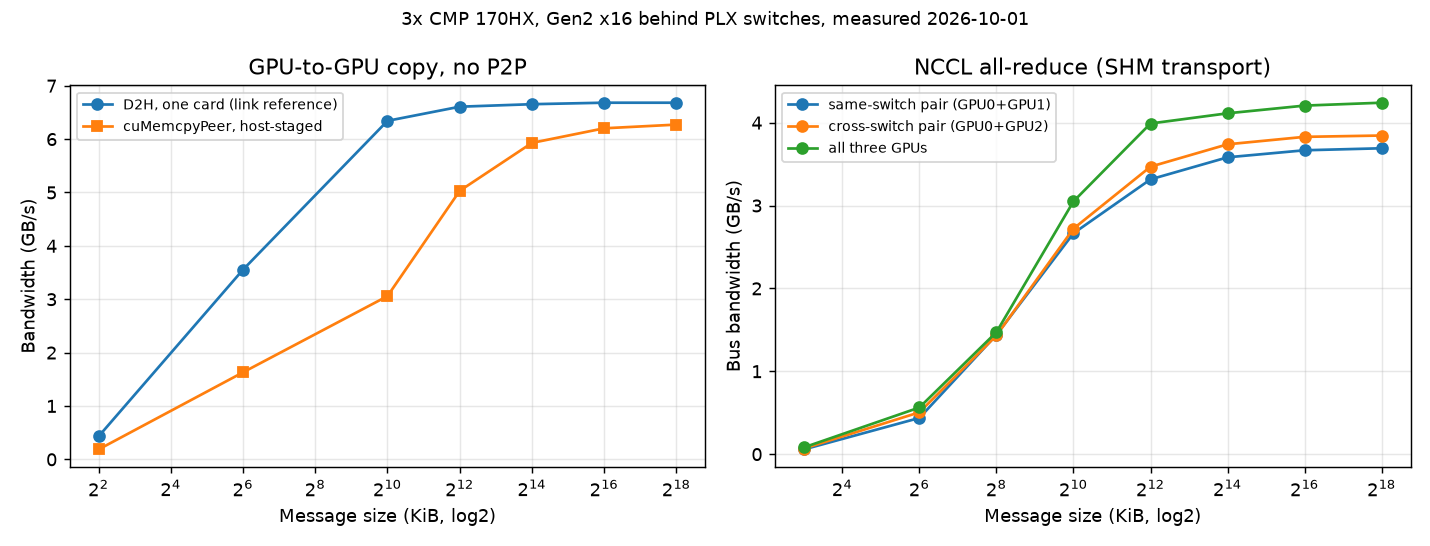

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
xs = sorted(peer)
a1.plot([x / 1024 for x in xs], [d2h[x]["GBps"] for x in xs], marker="o", label="D2H, one card (link reference)")
a1.plot([x / 1024 for x in xs], [statistics.median(p["GBps"] for p in peer[x]) for x in xs], marker="s", label="cuMemcpyPeer, host-staged")
a1.set_xscale("log", base=2); a1.set_xlabel("Message size (KiB, log2)"); a1.set_ylabel("Bandwidth (GB/s)")
a1.set_title("GPU-to-GPU copy, no P2P"); a1.grid(alpha=.3); a1.legend(fontsize=8)
for g in groups:
    a2.plot([s / 1024 for s in sizes], [groups[g][s]["busbw_GBps"] for s in sizes], marker="o", label=g)
a2.set_xscale("log", base=2); a2.set_xlabel("Message size (KiB, log2)"); a2.set_ylabel("Bus bandwidth (GB/s)")
a2.set_title("NCCL all-reduce (SHM transport)"); a2.grid(alpha=.3); a2.legend(fontsize=8)
fig.suptitle("3x CMP 170HX, Gen2 x16 behind PLX switches, measured 2026-10-01", fontsize=10)
fig.tight_layout()
chart = os.path.join("..", "assets", "charts", EXPERIMENT)
fig.savefig(chart + ".png", dpi=130); fig.savefig(chart + ".svg")
plt.close(fig)
display(Image(chart + ".png"))

## 3. Reproduce

**Hardware.** Two or more memory-unlocked CMP 170HX, forced airflow, live temperature
monitoring (stop at 80 °C core). The copy tools need only the NVIDIA driver (`libcuda`); the
all-reduce needs a CUDA-enabled PyTorch.

```bash
# peer access + alias-proof copy + bandwidth, every ordered pair
python3 results/2026-10-01-cmp170hx-3card-p2p-plx/tools/p2p_probe.py > p2p-copy.json
# copy time vs message size (4 KiB .. 256 MiB)
python3 results/2026-10-01-cmp170hx-3card-p2p-plx/tools/p2p_latency.py > p2p-latency.json
# NCCL all-reduce, e.g. two cards
docker run --rm --gpus '"device=0,1"' --ipc=host -v $PWD/results/2026-10-01-cmp170hx-3card-p2p-plx/tools:/t \
  --entrypoint torchrun ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-pp-20260905 \
  --nproc-per-node 2 /t/nccl_allreduce.py
```

Check the peer-access state and topology first:

```bash
nvidia-smi topo -m
nvidia-smi topo -p2p r     # GNS = not supported
```

### If several unlocked cards share a PCIe switch

The memory unlock resizes BAR1 to 64 GB on every card at driver load, from one probe thread
per GPU running at the same time. Cards behind a shared PLX switch then release and
re-assign the same bridge windows concurrently, which corrupted the kernel's resource tree on
this host (**measured:** crash in `__release_resource` under `pci_resize_resource`, slab
corruption, `Bad swap file entry`, random "BAR 1: no space" and cards failing to boot, within
15–90 s of every boot). [`patches/rebar-serialize.patch`](../results/2026-10-01-cmp170hx-3card-p2p-plx/patches/rebar-serialize.patch)
serializes the resize with one mutex; with it applied the host booted cleanly 9 times in a
row with all cards at Gen2 x16 and 64 GB. Hosts with one card per root port (no shared
switch) do not hit this.

## 4. Appendix

<details>
<summary>What was not tested, limitations, and next steps</summary>

- **Untested: true BAR1 P2P.** A community fork of the unlock (bayley/cmpunlocker) reports
  working BAR1 P2P on 4028GR-class hosts at 1.68 GB/s per direction on Gen2 **x4** links,
  with four driver patches, `RMForceStaticBar1=1;RMPcieP2PType=1`, and ACS redirect disabled.
  Those patches were not applied here, so this notebook is the no-P2P baseline for that A/B.
  Note that the staged path measured here (6.2 GB/s at x16) is already ~3.7× the fork's x4 P2P
  figure; the comparison that matters at x16 is small-message latency and all-reduce time.
- ACS request/completion redirect is enabled on the switch downstream ports (firmware
  default). It is irrelevant without P2P; with P2P it would force same-switch traffic through
  the root complex (the fork reports 1.20 vs 1.68 GB/s).
- One 256 MiB probe per pair, 10 timed repetitions; latency medians over 30 (≤16 MiB) or 8
  (larger) copies; all-reduce median of 20 after 5 warm-ups. No error bars beyond that.
- Power limit was the card default (250 W); copies are link-bound, not power-bound.
- Host topology details that are not needed to reproduce (bus addresses, serials, host
  names) are omitted by design.

</details>